In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

In [4]:

import numpy as np
import random

SEED = 42

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)



In [5]:
import yaml

BASE_PATH = "/content/drive/MyDrive/mosquito-robustness"

with open(os.path.join(BASE_PATH, "configs/config.yaml"), "r") as f:
    config = yaml.safe_load(f)
noise_levels = config["noise"]["sigmas"]
batch_size = config["training"]["batch_size"]

In [6]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

!unzip -q "/content/drive/MyDrive/images.zip" -d "/content/"

image_size = config["data"]["image_size"]

test_transforms = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(
        config["normalization"]["mean"],
        config["normalization"]["std"]
    )
])

base_dir = "/content/images"
test_dir = os.path.join(base_dir, "testing")

test_dataset = datasets.ImageFolder(test_dir, transform=test_transforms)

test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [8]:
# eff_model, res_model, swin_model already defined (NOTEBOOK 3 CODES)

import os
import yaml


BASE_PATH = "/content/drive/MyDrive/mosquito-robustness"







import torch.nn as nn
from torchvision import models

!unzip -q "/content/drive/MyDrive/images.zip" -d "/content/"
train_dir = "/content/images/training"
num_classes = len(os.listdir(train_dir))

print("Number of classes:", num_classes)

#efficientnet
def get_efficientnet(num_classes):
    model = models.efficientnet_b0(weights="IMAGENET1K_V1")

    in_features = model.classifier[1].in_features

    # Replace classifier
    model.classifier[1] = nn.Linear(in_features, num_classes)

    # Freeze backbone
    for param in model.features.parameters():
        param.requires_grad = False

    return model


def get_resnet(num_classes):
    model = models.resnet50(weights="IMAGENET1K_V1")

    in_features = model.fc.in_features

    model.fc = nn.Linear(in_features, num_classes)

    # Freeze backbone
    for name, param in model.named_parameters():
        if "fc" not in name:
            param.requires_grad = False

    return model


def get_swin(num_classes):
    model = models.swin_v2_t(weights="IMAGENET1K_V1")

    in_features = model.head.in_features

    model.head = nn.Linear(in_features, num_classes)

    # Freeze backbone
    for name, param in model.named_parameters():
        if "head" not in name:
            param.requires_grad = False

    return model


class ModelWithEmbedding(nn.Module):
    def __init__(self, model, model_name):
        super().__init__()
        self.model = model
        self.model_name = model_name

    def forward(self, x):
        if self.model_name == "resnet":
            # Extract features before FC
            features = self.model.avgpool(self.model.layer4(
                        self.model.layer3(
                        self.model.layer2(
                        self.model.layer1(
                        self.model.maxpool(
                        self.model.relu(
                        self.model.bn1(
                        self.model.conv1(x)))))))))
            features = torch.flatten(features, 1)
            logits = self.model.fc(features)

        elif self.model_name == "efficientnet":
            features = self.model.features(x)
            features = self.model.avgpool(features)
            features = torch.flatten(features, 1)
            logits = self.model.classifier(features)

        elif self.model_name == "swin":

            x=self.model.features(x)

            x=self.model.norm(x)

            features = x.mean(dim=(1,2))

            logits = self.model.head(features)
        return features, logits


eff_model = get_efficientnet(num_classes)
res_model = get_resnet(num_classes)
swin_model = get_swin(num_classes)
eff_model = ModelWithEmbedding(eff_model, "efficientnet").to(device)
res_model = ModelWithEmbedding(res_model, "resnet").to(device)
swin_model = ModelWithEmbedding(swin_model, "swin").to(device)

print("Models initialized.")




replace /content/images/testing/Aedes Aegypti/Aedes Aegypti_401.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
Number of classes: 6
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 107MB/s] 


Downloading: "https://download.pytorch.org/models/swin_v2_t-b137f0e2.pth" to /root/.cache/torch/hub/checkpoints/swin_v2_t-b137f0e2.pth


100%|██████████| 109M/109M [00:00<00:00, 131MB/s] 


Models initialized.


In [9]:
eff_model.load_state_dict(torch.load("/content/drive/MyDrive/mosquito-robustness/models/efficientnet.pth"))
res_model.load_state_dict(torch.load("/content/drive/MyDrive/mosquito-robustness/models/resnet.pth"))
swin_model.load_state_dict(torch.load("/content/drive/MyDrive/mosquito-robustness/models/swin.pth"))

eff_model.to(device).eval()
res_model.to(device).eval()
swin_model.to(device).eval()

ModelWithEmbedding(
  (model): SwinTransformer(
    (features): Sequential(
      (0): Sequential(
        (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
        (1): Permute()
        (2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
      )
      (1): Sequential(
        (0): SwinTransformerBlockV2(
          (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
          (attn): ShiftedWindowAttentionV2(
            (qkv): Linear(in_features=96, out_features=288, bias=True)
            (proj): Linear(in_features=96, out_features=96, bias=True)
            (cpb_mlp): Sequential(
              (0): Linear(in_features=2, out_features=512, bias=True)
              (1): ReLU(inplace=True)
              (2): Linear(in_features=512, out_features=3, bias=False)
            )
          )
          (stochastic_depth): StochasticDepth(p=0.0, mode=row)
          (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
          (mlp): MLP(
            (0): Linear(in_

In [10]:
def add_gaussian_noise(images, sigma):
    noise = torch.randn_like(images) * sigma
    return images + noise

In [11]:
def get_embeddings(model, images):
    features, _ = model(images)
    features = F.normalize(features, p=2, dim=1)  # critical
    return features

In [12]:


def cosine_similarity(a, b):
    return (a * b).sum(dim=1).mean().item()

In [14]:
def evaluate_embedding_metrics(model, loader, device, sigmas):
    model.eval()

    cosine_results = {}
    l2_results = {}

    for sigma in sigmas:
        cos_vals = []
        l2_vals = []

        for images, _ in loader:
            images = images.to(device)

            noisy_images = add_gaussian_noise(images, sigma)

            with torch.no_grad():
                e_clean = get_embeddings(model, images)
                e_noisy = get_embeddings(model, noisy_images)

            # Normalize embeddings ONCE
            e_clean = F.normalize(e_clean, dim=1)
            e_noisy = F.normalize(e_noisy, dim=1)

            # ✅ Use your cosine_similarity function
            cos_sim = cosine_similarity(e_clean, e_noisy)

            # ✅ L2 distance on normalized embeddings
            l2_dist = torch.norm(e_clean - e_noisy, dim=1).mean().item()

            cos_vals.append(cos_sim)
            l2_vals.append(l2_dist)

        cosine_results[sigma] = sum(cos_vals) / len(cos_vals)
        l2_results[sigma] = sum(l2_vals) / len(l2_vals)

        print(f"Sigma {sigma}: Cosine={cosine_results[sigma]:.4f}, L2={l2_results[sigma]:.4f}")

    return cosine_results, l2_results

In [15]:
sigmas = noise_levels
print(sigmas)

[0.0, 0.05, 0.1, 0.15, 0.2]


In [16]:
print("\nEfficientNet Metrics")
eff_cos, eff_l2 = evaluate_embedding_metrics(eff_model, test_loader, device, sigmas)

print("\nResNet Metrics")
res_cos, res_l2 = evaluate_embedding_metrics(res_model, test_loader, device, sigmas)

print("\nSwin Metrics")
swin_cos, swin_l2 = evaluate_embedding_metrics(swin_model, test_loader, device, sigmas)


EfficientNet Metrics
Sigma 0.0: Cosine=1.0000, L2=0.0000
Sigma 0.05: Cosine=0.1343, L2=1.3097
Sigma 0.1: Cosine=-0.0030, L2=1.4142
Sigma 0.15: Cosine=-0.0470, L2=1.4459
Sigma 0.2: Cosine=-0.0849, L2=1.4722

ResNet Metrics
Sigma 0.0: Cosine=1.0000, L2=0.0000
Sigma 0.05: Cosine=0.8810, L2=0.4811
Sigma 0.1: Cosine=0.8091, L2=0.6134
Sigma 0.15: Cosine=0.7657, L2=0.6808
Sigma 0.2: Cosine=0.7324, L2=0.7286

Swin Metrics
Sigma 0.0: Cosine=1.0000, L2=0.0000
Sigma 0.05: Cosine=0.9076, L2=0.4204
Sigma 0.1: Cosine=0.8311, L2=0.5725
Sigma 0.15: Cosine=0.7667, L2=0.6741
Sigma 0.2: Cosine=0.7127, L2=0.7486


In [17]:
eff_cos_vals = [eff_cos[s] for s in sigmas]
res_cos_vals = [res_cos[s] for s in sigmas]
swin_cos_vals = [swin_cos[s] for s in sigmas]

eff_l2_vals = [eff_l2[s] for s in sigmas]
res_l2_vals = [res_l2[s] for s in sigmas]
swin_l2_vals = [swin_l2[s] for s in sigmas]

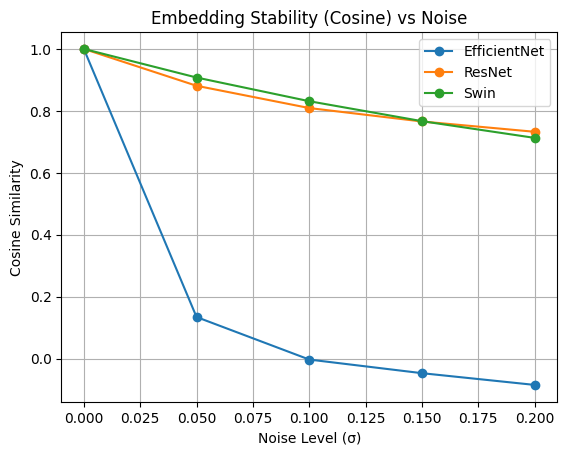

In [18]:
plt.figure()

plt.plot(sigmas, eff_cos_vals, marker='o', label="EfficientNet")
plt.plot(sigmas, res_cos_vals, marker='o', label="ResNet")
plt.plot(sigmas, swin_cos_vals, marker='o', label="Swin")

plt.xlabel("Noise Level (σ)")
plt.ylabel("Cosine Similarity")
plt.title("Embedding Stability (Cosine) vs Noise")

plt.legend()
plt.grid()
plt.show()

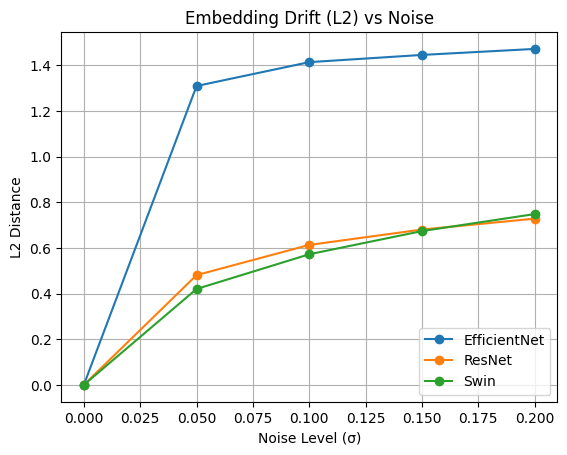

In [19]:
plt.figure()

plt.plot(sigmas, eff_l2_vals, marker='o', label="EfficientNet")
plt.plot(sigmas, res_l2_vals, marker='o', label="ResNet")
plt.plot(sigmas, swin_l2_vals, marker='o', label="Swin")

plt.xlabel("Noise Level (σ)")
plt.ylabel("L2 Distance")
plt.title("Embedding Drift (L2) vs Noise")

plt.legend()
plt.grid()
plt.show()